# **Midterm Project**

## Data Preparation

In [388]:
import pandas as pd

# Load daily stock data to dataframes
universe = ['AAPL','AMZN','GOOG','IBM','META','MSFT','NFLX','ORCL','SAP','TSLA']
data = {}

for ticker in universe:
    df = pd.read_csv(f'{ticker}.csv', index_col=0)
    df.index = pd.to_datetime(df.index, format='%d-%b-%y', errors='coerce')
    data[ticker] = df

usdjpy = pd.read_csv('usdjpy.csv', encoding='cp1252')

## Close Data

In [389]:
# Extract close and adj close data
close_data = pd.DataFrame()

for ticker, df in data.items():
    close_data[f'{ticker} Close'] = df['Close']
    close_data[f'{ticker} Adj Close'] = df['Adj Close']

# Extra precaution
close_data.sort_index(inplace=True)

print(close_data.head())

            AAPL Close  AAPL Adj Close  AMZN Close  AMZN Adj Close  \
Date                                                                 
2018-01-02       43.06           40.57       59.45           59.45   
2018-01-03       43.06           40.56       60.21           60.21   
2018-01-04       43.26           40.75       60.48           60.48   
2018-01-05       43.75           41.21       61.46           61.46   
2018-01-08       43.59           41.06       62.34           62.34   

            GOOG Close  GOOG Adj Close  IBM Close  IBM Adj Close  META Close  \
Date                                                                           
2018-01-02       53.25           53.12     147.47         107.53      181.42   
2018-01-03       54.12           53.99     151.52         110.49      184.67   
2018-01-04       54.32           54.19     154.59         112.72      184.33   
2018-01-05       55.11           54.98     155.34         113.27      186.85   
2018-01-08       55.35       

## 1.1 Portfolio set-up

In [390]:
class Portfolio:
    def __init__(self, tickers, initial_cash=5e6, start_date='2018-01-01'):
        self.cash = initial_cash
        self.tickers = tickers
        self.start_date = pd.to_datetime(start_date)
        
        # each ticker has its own transaction DataFrame
        self.holdings = {
            t: pd.DataFrame([{
                'Buy/Sell': 0,
                'Stock Price': 0.0,
                'Delta Shares': 0.0,
                'Current Holdings': 0,
                'Current Value': 0.0
            }], index=[self.start_date])
            for t in tickers
        }

    @staticmethod
    def _closest_trading_date(date, price_data):
        """Return the closest previous trading date in price_data if date is missing."""
        date = pd.to_datetime(date)
        if date not in price_data.index:
            # method='ffill' finds previous available date
            idx = price_data.index.get_indexer([date], method='ffill')[0]
            date = price_data.index[idx]
        return date

    def buy(self, ticker, trade_date, price, shares):
        cost = price * shares
        if cost > self.cash:
            print(f"⚠️ Not enough cash to buy {shares} shares of {ticker}")
            return
        self.cash -= cost
        prev = self.holdings[ticker].iloc[-1]['Current Holdings']
        new = prev + shares
        self.holdings[ticker].loc[pd.to_datetime(trade_date)] = {
            'Buy/Sell': 1,
            'Stock Price': price,
            'Delta Shares': shares,
            'Current Holdings': new,
            'Current Value': new * price
        }

    def sell(self, ticker, trade_date, price, shares):
        prev = self.holdings[ticker].iloc[-1]['Current Holdings']
        if shares > prev:
            print(f"⚠️ Not enough shares to sell {shares} of {ticker}")
            return
        proceeds = price * shares
        self.cash += proceeds
        new = prev - shares
        self.holdings[ticker].loc[pd.to_datetime(trade_date)] = {
            'Buy/Sell': 0,
            'Stock Price': price,
            'Delta Shares': -shares,
            'Current Holdings': new,
            'Current Value': new * price
        }

    def liquidate(self, date, close_data):
        """
        Sell all current holdings of all tickers at 'Close' prices on the given date.
        Automatically picks the closest previous trading day if date is not available.
        """
        date = self._closest_trading_date(date, close_data)
        for ticker in self.tickers:
            shares = self.holdings[ticker].iloc[-1]['Current Holdings']
            if shares > 0:
                price = close_data.loc[date, f'{ticker} Close']
                self.sell(ticker, date, price, shares)

    def get_value(self, prices, date):
        """Compute total mark-to-market value given price data and date."""
        date = self._closest_trading_date(date, prices)
        total_value = self.cash
        for t in self.tickers:
            px = prices.loc[date, f'{t} Close']
            shares = self.holdings[t].iloc[-1]['Current Holdings']
            total_value += shares * px
        return total_value

    def mtm(self):
        """
        Compute total mark-to-market portfolio value using the last known
        stock price for each holding (from the portfolio DataFrames) + cash.
        """
        total_value = self.cash
        for ticker in self.tickers:
            df = self.holdings[ticker]
            if not df.empty:
                last_row = df.iloc[-1]
                shares = last_row['Current Holdings']
                price = last_row['Stock Price']
                total_value += shares * price
        return total_value


## 1.2 Initial trades

In [391]:
pyport_low = Portfolio(universe)
pyport_high = Portfolio(universe)
allocation = 1e6
buy_list = ['IBM','MSFT','GOOG','AAPL','AMZN']
trade_date = '2018-01-02'

for ticker in buy_list:
    price = close_data.loc[trade_date, f'{ticker} Close']
    shares = int(allocation // price)
    pyport_low.buy(ticker, trade_date, price, shares)
    pyport_high.buy(ticker,trade_date, price, shares)

print(f"Remaining cash: ${pyport_low.cash:,.2f}")
for t in pyport_low.tickers:
    print(f"{t} holdings: {pyport_low.holdings[t].iloc[-1]['Current Holdings']}")

Remaining cash: $150.50
AAPL holdings: 23223.0
AMZN holdings: 16820.0
GOOG holdings: 18779.0
IBM holdings: 6781.0
META holdings: 0.0
MSFT holdings: 11634.0
NFLX holdings: 0.0
ORCL holdings: 0.0
SAP holdings: 0.0
TSLA holdings: 0.0


## 2.1 Rebalancing low strategy

In [392]:
def rebal_low(date, adj_close_data, top_n=5):
    """
    Find the top_n stocks that dropped the most in Adj Close over the past 5 business days.
    Automatically adjusts for holidays/weekends by using the closest previous available date.
    """
    date = pd.to_datetime(date)

    # Find the closest previous available date in the index
    if date not in adj_close_data.index:
        date = adj_close_data.index[adj_close_data.index.get_indexer([date], method='ffill')[0]]

    prev_date_idx = adj_close_data.index.get_loc(date) - 5
    if prev_date_idx < 0:
        raise ValueError("Not enough historical data for 5-day drop calculation.")
    
    prev_date = adj_close_data.index[prev_date_idx]

    # Compute percentage change over the 5 days
    pct_change = {}
    for ticker in universe:
        start_price = adj_close_data.loc[prev_date, f'{ticker} Adj Close']
        end_price = adj_close_data.loc[date, f'{ticker} Adj Close']
        pct_change[ticker] = (end_price - start_price) / start_price

    # Sort by percentage drop (most negative first)
    sorted_drop = sorted(pct_change.items(), key=lambda x: x[1])
    
    # Return the tickers of the top_n largest drops
    tickers_to_buy = [ticker for ticker, change in sorted_drop[:top_n]]
    
    return tickers_to_buy


## 2.2 Five day increments

In [393]:
start_date = pd.to_datetime('2018-01-09')
transaction_days = close_data.index[close_data.index >= start_date][::5]

## Implement rebalancing low trading strategy

In [394]:
mtm_history_rebal_low = pd.Series(index=transaction_days, dtype=float)

for day in transaction_days:
    pyport_low.liquidate(day, close_data)
    tickers_to_buy = rebal_low(day, close_data)
    print(tickers_to_buy)
    allocation_per_stock = pyport_low.cash / len(tickers_to_buy)
    
    for ticker in tickers_to_buy:
        price = close_data.loc[pyport_low._closest_trading_date(day, close_data), f'{ticker} Close']
        shares = int(allocation_per_stock // price)
        pyport_low.buy(ticker, day, price, shares)
    
    mtm_history_rebal_low[day] = pyport_low.mtm()

mtm_history_rebal_low = mtm_history_rebal_low.sort_index()

['AAPL', 'SAP', 'MSFT', 'META', 'GOOG']
['META', 'SAP', 'MSFT', 'GOOG', 'ORCL']
['AAPL', 'IBM', 'TSLA', 'MSFT', 'ORCL']
['AAPL', 'IBM', 'SAP', 'META', 'ORCL']
['GOOG', 'SAP', 'IBM', 'MSFT', 'ORCL']
['TSLA', 'META', 'SAP', 'NFLX', 'ORCL']
['IBM', 'SAP', 'META', 'ORCL', 'MSFT']
['TSLA', 'GOOG', 'SAP', 'META', 'ORCL']
['TSLA', 'AAPL', 'IBM', 'MSFT', 'META']
['TSLA', 'MSFT', 'SAP', 'ORCL', 'META']
['ORCL', 'META', 'GOOG', 'AAPL', 'TSLA']
['TSLA', 'AMZN', 'NFLX', 'META', 'GOOG']
['AMZN', 'GOOG', 'NFLX', 'ORCL', 'IBM']
['TSLA', 'AMZN', 'GOOG', 'SAP', 'ORCL']
['IBM', 'AAPL', 'TSLA', 'SAP', 'ORCL']
['NFLX', 'GOOG', 'AAPL', 'ORCL', 'MSFT']
['IBM', 'MSFT', 'TSLA', 'ORCL', 'AMZN']
['IBM', 'AMZN', 'SAP', 'NFLX', 'TSLA']
['TSLA', 'GOOG', 'META', 'AMZN', 'AAPL']
['IBM', 'SAP', 'TSLA', 'GOOG', 'AAPL']
['IBM', 'SAP', 'ORCL', 'AAPL', 'NFLX']
['META', 'GOOG', 'MSFT', 'AAPL', 'NFLX']
['ORCL', 'IBM', 'AAPL', 'SAP', 'MSFT']
['TSLA', 'ORCL', 'GOOG', 'IBM', 'AMZN']
['SAP', 'GOOG', 'META', 'TSLA', 'IBM']
['TS

## 6.1 Rebalancing high strategy

In [395]:
def rebal_high(date, adj_close_data, top_n=5):
    date = pd.to_datetime(date)
    prev_idx = adj_close_data.index.get_indexer([date], method='ffill')[0] - 5
    if prev_idx < 0:
        raise ValueError("Not enough historical data for 5-day surge calculation.")
    prev_date = adj_close_data.index[prev_idx]

    pct_change = (adj_close_data.loc[date] - adj_close_data.loc[prev_date]) / adj_close_data.loc[prev_date]
    pct_change = pct_change.dropna()
    top_stocks = pct_change.nlargest(top_n).index.tolist()
    
    # Strip both suffixes to return clean ticker names
    top_stocks = [s.replace(' Adj Close', '').replace(' Close', '') for s in top_stocks]
    
    return top_stocks


## 6.2 Implement rebalancing high

In [396]:
mtm_history_rebal_high = pd.Series(index=transaction_days, dtype=float)

for day in transaction_days:
    # Sell all current positions first
    pyport_high.liquidate(day, close_data)
    
    # Get tickers to buy using the rebal_high strategy
    tickers_to_buy = rebal_high(day, close_data)
    print(tickers_to_buy)
    
    # Split cash evenly among chosen stocks
    allocation_per_stock = pyport_high.cash / len(tickers_to_buy)
    
    # Buy shares of each selected stock
    for ticker in tickers_to_buy:
        price = close_data.loc[
            pyport_high._closest_trading_date(day, close_data),
            f'{ticker} Close'
        ]
        shares = int(allocation_per_stock // price)
        pyport_high.buy(ticker, day, price, shares)
    
    # Record mark-to-market value for the day
    mtm_history_rebal_high[day] = pyport_high.mtm()

# Sort MTM history chronologically
mtm_history_rebal_high = mtm_history_rebal_high.sort_index()


['IBM', 'IBM', 'ORCL', 'AMZN', 'AMZN']
['TSLA', 'TSLA', 'NFLX', 'NFLX', 'AMZN']
['NFLX', 'NFLX', 'META', 'META', 'AMZN']
['AMZN', 'AMZN', 'MSFT', 'MSFT', 'NFLX']
['NFLX', 'NFLX', 'AMZN', 'AMZN', 'TSLA']
['AAPL', 'AAPL', 'AMZN', 'AMZN', 'GOOG']
['TSLA', 'TSLA', 'NFLX', 'NFLX', 'GOOG']
['NFLX', 'NFLX', 'AAPL', 'AAPL', 'MSFT']
['NFLX', 'NFLX', 'SAP', 'SAP', 'GOOG']
['IBM', 'IBM', 'GOOG', 'GOOG', 'AMZN']
['AMZN', 'AMZN', 'SAP', 'SAP', 'NFLX']
['MSFT', 'MSFT', 'SAP', 'SAP', 'IBM']
['TSLA', 'TSLA', 'AAPL', 'AAPL', 'SAP']
['NFLX', 'NFLX', 'META', 'META', 'IBM']
['AMZN', 'AMZN', 'NFLX', 'NFLX', 'GOOG']
['SAP', 'SAP', 'META', 'META', 'AMZN']
['AAPL', 'AAPL', 'NFLX', 'NFLX', 'SAP']
['META', 'META', 'GOOG', 'GOOG', 'AAPL']
['IBM', 'IBM', 'NFLX', 'NFLX', 'MSFT']
['NFLX', 'NFLX', 'AMZN', 'AMZN', 'MSFT']
['TSLA', 'TSLA', 'GOOG', 'GOOG', 'META']
['TSLA', 'TSLA', 'SAP', 'SAP', 'IBM']
['TSLA', 'TSLA', 'NFLX', 'NFLX', 'GOOG']
['META', 'META', 'NFLX', 'NFLX', 'MSFT']
['NFLX', 'NFLX', 'AMZN', 'AMZN', 'AAP

## 7. High tech index

In [397]:
close_columns = [col for col in close_data.columns if col.endswith(' Close') and not col.endswith('Adj Close')]
high_tech_index = close_data[close_columns].mean(axis=1).rename('High Tech Index')

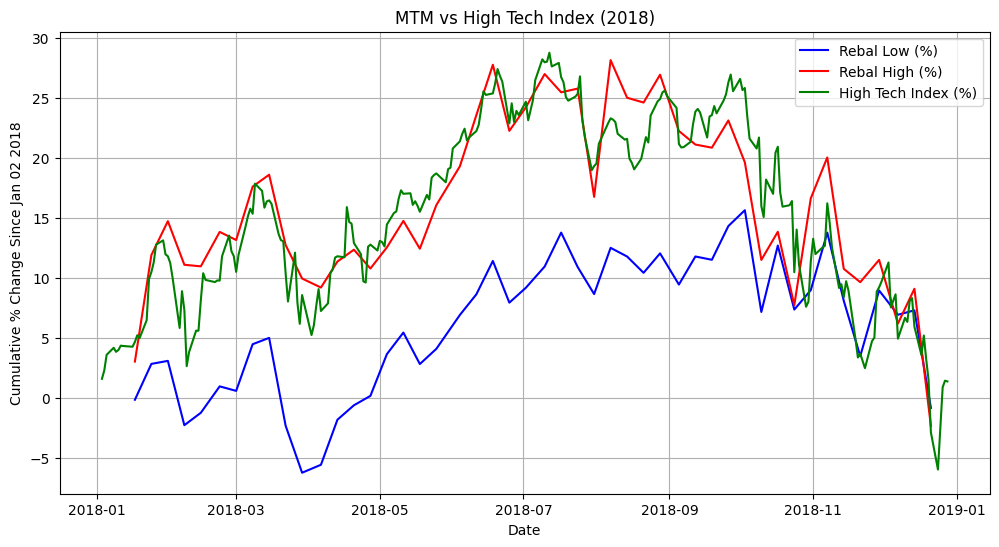

In [398]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(mtm_history_rebal_low.pct_change().cumsum() * 100, label='Rebal Low (%)', color='blue')
plt.plot(mtm_history_rebal_high.pct_change().cumsum() * 100, label='Rebal High (%)', color='red')
plt.plot(high_tech_index.pct_change().cumsum() * 100, label='High Tech Index (%)', color='green')

plt.title('MTM vs High Tech Index (2018)')
plt.xlabel('Date')
plt.ylabel('Cumulative % Change Since Jan 02 2018')
plt.legend()
plt.grid(True)
plt.show()


## 8 Conversion to Yen

In [400]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Step 1: Prepare USD/JPY ---
usdjpy = usdjpy.copy()
usdjpy["Date"] = pd.to_datetime(usdjpy["Date"])
usdjpy = usdjpy.sort_values("Date")
usdjpy.set_index("Date", inplace=True)

# --- Step 2: Prepare MTM in USD ---
mtm_usd = mtm_history_rebal_high.copy()
mtm_usd.index = pd.to_datetime(mtm_usd.index)
mtm_usd = mtm_usd.sort_index()

# --- Step 3: Align MTM with USD/JPY by date ---
# Only keep dates that exist in both datasets
common_dates = mtm_usd.index.intersection(usdjpy.index)
mtm_usd_aligned = mtm_usd.loc[common_dates]
usd_to_jpy_aligned = usdjpy.loc[common_dates, "Close"]

# --- Step 4: Convert MTM to JPY ---
mtm_jpy_aligned = mtm_usd_aligned * usd_to_jpy_aligned

# --- Step 5: Convert to percentage change from first day ---
mtm_usd_pct = (mtm_usd_aligned / mtm_usd_aligned.iloc[0] - 1) * 100
mtm_jpy_pct = (mtm_jpy_aligned / mtm_jpy_aligned.iloc[0] - 1) * 100

# --- Step 6: Plot ---
plt.figure(figsize=(12, 6))
plt.plot(mtm_usd_pct.index, mtm_usd_pct, label='MTM in USD (%)', color='blue')
plt.plot(mtm_jpy_pct.index, mtm_jpy_pct, label='MTM in JPY (%)', color='orange')

# Format x-axis nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.title('MTM Portfolio Value in USD vs JPY (2018)')
plt.xlabel('Date')
plt.ylabel('Percentage Change Since First Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


KeyError: 'Date'